In [1]:
import numpy as np
import scipy as sp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.font_manager import FontProperties
from tqdm import tqdm

from bell_coupling_circuit_revisited_2 import BellCircuit

plt.style.use('science')

h = 6.62607015e-34
hbar = 1.054571817e-34
e = 1.60217663e-19
phi0 = h / (2*e)

BellCircuit class has been imported!


Energy spectrum

Probe qubit energies:
EJp = 5.000 GHz, ECp = 9.685 GHz, ELp = 0.817 GHz


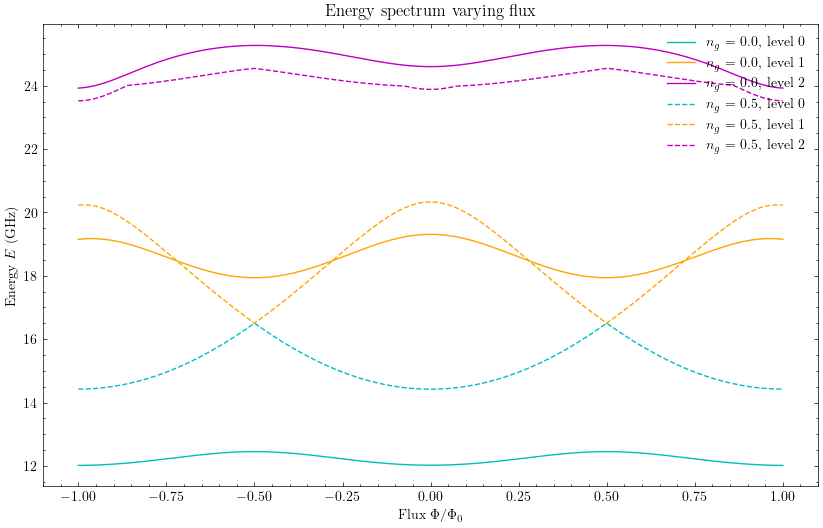

In [2]:
system = BellCircuit(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

# probe qubit energies
EJp = system.Ejp / 1e9 / h
ECp = (e**2) / (2*system.Cjp*h) / 1e9
ELp = (phi0**2) / (4*np.pi**2*system.Lp*h) / 1e9

print("Probe qubit energies:")
print(f"EJp = {EJp:.3f} GHz, ECp = {ECp:.3f} GHz, ELp = {ELp:.3f} GHz")

flux_list = np.linspace(-1,1,201)
ng_list = [0.0, 0.5]

plt.figure(figsize=(10, 6))

for ng in ng_list:
    system.ng = ng
    evals_list = []
    
    for flux in flux_list:
        system.flux = flux
        evals, evecs = system.diagonalise_fluxonium(update=True)
        evals_list.append(evals[:3])

    evals_list = np.array(evals_list)
    evals_list = evals_list * 1e-9 / h
    
    label = f"$n_g$ = {ng}"
    for i, color in zip(range(3), ['c', 'orange', 'm']):
        plt.plot(flux_list, evals_list[:, i], color=color, linestyle='-' if ng==0 else '--', label=f'{label}, level {i}')

plt.title("Energy spectrum varying flux")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Energy $E$ (GHz)")
plt.legend()
plt.show()

Transition frequency

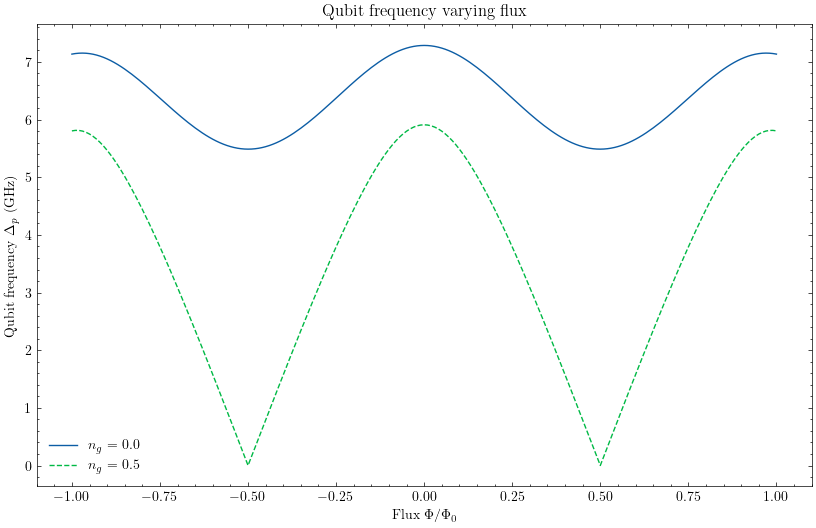

In [3]:
plt.figure(figsize=(10, 6))

for ng in ng_list:
    system.ng = ng
    freq_list = []

    for phi in flux_list:
        system.flux = phi
        evals, evecs = system.diagonalise_fluxonium(update = True)
        freq = system.get_fluxonium_frequency()
        freq_list.append(freq)
    
    label = f"$n_g$ = {ng}"
    plt.plot(flux_list, freq_list, linestyle='-' if ng==0 else '--', label=f'{label}')

plt.title("Qubit frequency varying flux")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Qubit frequency $\\Delta_p$ (GHz)")
plt.legend()
plt.show()

Qubit gap at ng=0.25: 4.796 GHz


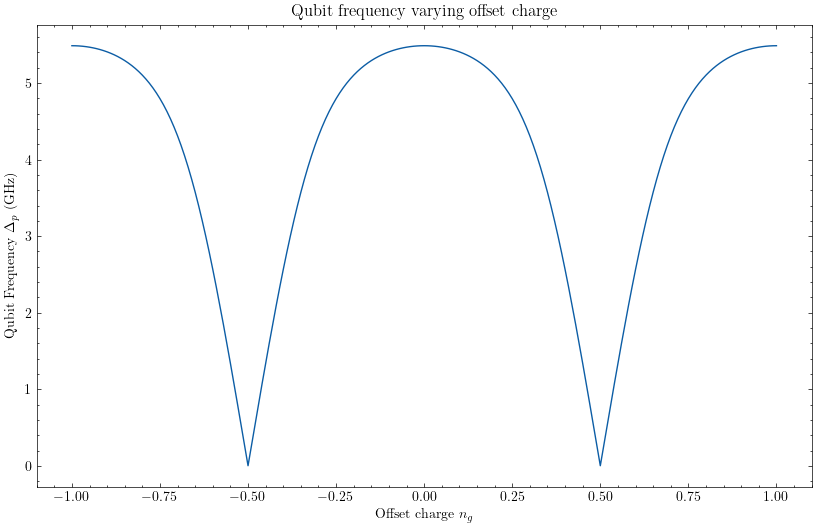

In [4]:
system = BellCircuit(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)


ng_list_2 = np.linspace(-1, 1, 201)
freq_list_ng = []

for ng in ng_list_2:
    system.ng = ng
    evals, evecs = system.diagonalise_fluxonium(update = True)
    freq = system.get_fluxonium_frequency()
    freq_list_ng.append(freq)

    if ng==0.25:
        print(f"Qubit gap at ng=0.25: {freq:.3f} GHz")

plt.figure(figsize=(10, 6))
plt.plot(ng_list_2, freq_list_ng)
plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit Frequency $\\Delta_p$ (GHz)")
plt.title("Qubit frequency varying offset charge")
plt.show()

Transverse and longitudinal coupling

Transverse coupling strength at ng=0.25: 0.111 GHz
Longitudinal coupling strength at ng=0.25: 231.151 GHz


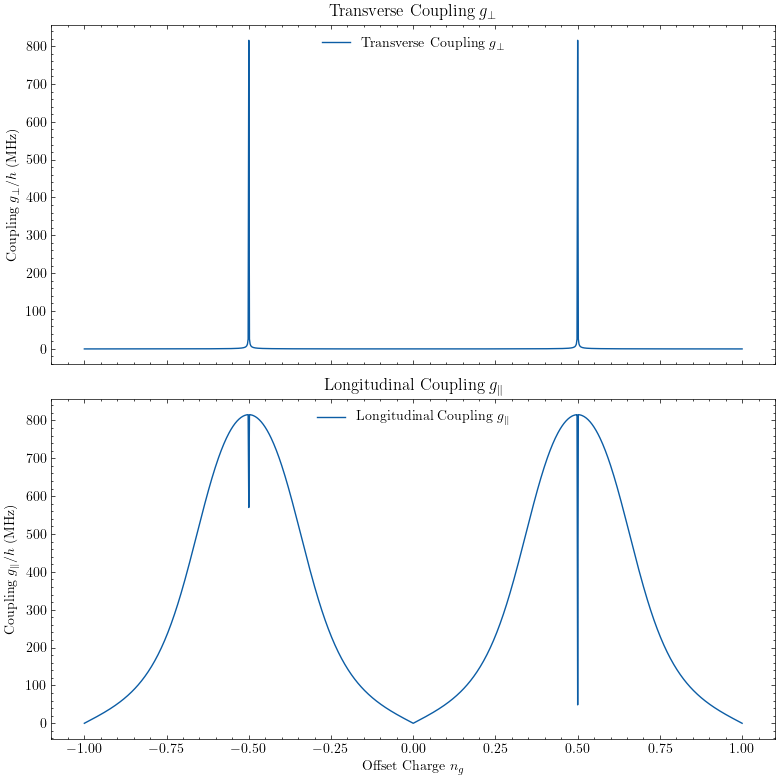

In [29]:
system = BellCircuit(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=0.5, ng=0.0, ncut=5)

ng_list_2 = np.linspace(-1, 1, 1001)

# transverse and longitudinal coupling between probe and resonator
g_transverse_ng = []
g_longitudinal_ng = []

for ng in ng_list_2:
    system.ng = ng
    
    g_perp = system.calc_g_perp(update = True)  # transverse coupling
    g_perp = np.abs(g_perp)  # transverse coupling strength
    
    g_parr = system.calc_g_parr(update = True)  # longitudinal coupling
    g_parr = np.abs(g_parr)  # longitudinal coupling strength

    g_transverse_ng.append(g_perp)
    g_longitudinal_ng.append(g_parr)

    if ng==0.25:
        print(f"Transverse coupling strength at ng=0.25: {g_perp:.3f} GHz")
        print(f"Longitudinal coupling strength at ng=0.25: {g_parr:.3f} GHz")

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(ng_list_2, g_transverse_ng, label="Transverse Coupling $g_\\perp$")
axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].plot(ng_list_2, g_longitudinal_ng, label="Longitudinal Coupling $g_\\parallel$")
axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

Protected from flux detuning

 63%|█████████████████████████████████████████████████▍                             | 627/1001 [01:25<00:52,  7.17it/s]

Flux=0.5100, longitudinal coupling at ng=0.25: 231.069 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [01:25<00:45,  8.16it/s]

Flux=0.5010, longitudinal coupling at ng=0.25: 231.150 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [01:25<00:46,  8.02it/s]

Flux=0.5001, longitudinal coupling at ng=0.25: 231.151 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [01:25<00:47,  7.91it/s]

Flux=0.5000, longitudinal coupling at ng=0.25: 231.151 GHz


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [02:15<00:00,  7.41it/s]


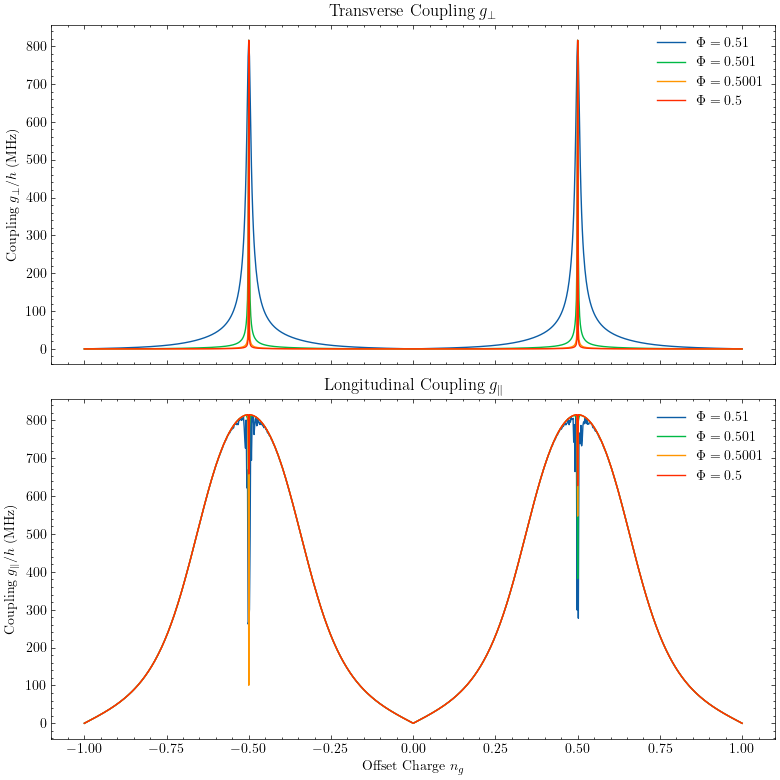

In [5]:
ng_vals = np.linspace(-1, 1, 1001)
flux_vals = [0.51, 0.501, 0.5001, 0.5]
results = {}

for flux in flux_vals:
    system = BellCircuit(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=flux, ng=0.0, ncut=5)
    
    g_transverse_ng = []
    g_longitudinal_ng = []
    
    for ng in tqdm(ng_vals):
        system.ng = ng
        
        g_perp = np.abs(system.calc_g_perp(update=True))   # transverse
        g_parr = np.abs(system.calc_g_parr(update=True))   # longitudinal
        
        g_transverse_ng.append(g_perp)
        g_longitudinal_ng.append(g_parr)

        if ng==0.25:
            print(f"Flux={flux:.4f}, longitudinal coupling at ng=0.25: {g_parr:.3f} GHz")
    
    results[flux] = (g_transverse_ng, g_longitudinal_ng)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for flux in flux_vals:
    g_transverse_ng, g_longitudinal_ng = results[flux]
    axs[0].plot(ng_vals, g_transverse_ng, label=f"$\Phi={flux}$")
    axs[1].plot(ng_vals, g_longitudinal_ng, label=f"$\Phi={flux}$")

axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

In [11]:
from bell_coupling_circuit_asymmetric import BellCircuit2

system2 = BellCircuit2(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=flux, ng=0.0, ncut=5, alpha=0.9)

Protected from junction asymmetry

 63%|█████████████████████████████████████████████████▍                             | 626/1001 [02:44<02:22,  2.64it/s]

Junction asymmetry=0.90, longitudinal coupling at ng=0.25: 215.632 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [04:32<01:04,  5.82it/s]

Junction asymmetry=0.95, longitudinal coupling at ng=0.25: 224.265 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [02:06<01:09,  5.38it/s]

Junction asymmetry=0.99, longitudinal coupling at ng=0.25: 229.923 GHz


 63%|█████████████████████████████████████████████████▍                             | 626/1001 [02:37<01:32,  4.07it/s]

Junction asymmetry=1.00, longitudinal coupling at ng=0.25: 231.151 GHz


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [04:05<00:00,  4.07it/s]


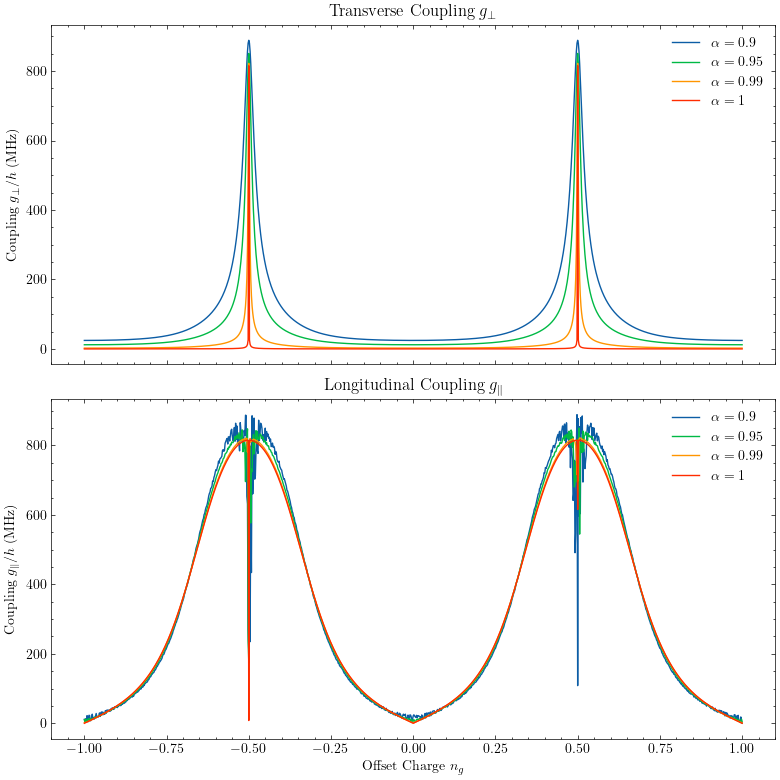

In [12]:
ng_vals = np.linspace(-1, 1, 1001)
alpha_vals = [0.9, 0.95, 0.99, 1]
results = {}

for alpha in alpha_vals:
    system2 = BellCircuit2(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=flux, ng=0.0, ncut=5, alpha=alpha)
    
    g_transverse_ng = []
    g_longitudinal_ng = []
    
    for ng in tqdm(ng_vals):
        system2.ng = ng
        
        g_perp = np.abs(system2.calc_g_perp(update=True))   # transverse
        g_parr = np.abs(system2.calc_g_parr(update=True))   # longitudinal
        
        g_transverse_ng.append(g_perp)
        g_longitudinal_ng.append(g_parr)

        if ng==0.25:
            print(f"Junction asymmetry={alpha:.2f}, longitudinal coupling at ng=0.25: {g_parr:.3f} GHz")
    
    results[alpha] = (g_transverse_ng, g_longitudinal_ng)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for alpha in alpha_vals:
    g_transverse_ng, g_longitudinal_ng = results[alpha]
    axs[0].plot(ng_vals, g_transverse_ng, label=fr"$\alpha={alpha}$")
    axs[1].plot(ng_vals, g_longitudinal_ng, label=fr"$\alpha={alpha}$")

axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()

 63%|█████████████████████████████████████████████████▍                             | 626/1001 [02:04<01:15,  4.98it/s]

Junction asymmetry=0.99, longitudinal coupling at ng=0.25: 229.945 GHz


 63%|█████████████████████████████████████████████████▍                             | 626/1001 [02:03<01:19,  4.74it/s]

Junction asymmetry=1.00, longitudinal coupling at ng=0.25: 231.031 GHz


 63%|█████████████████████████████████████████████████▍                             | 627/1001 [02:02<01:11,  5.24it/s]

Junction asymmetry=1.00, longitudinal coupling at ng=0.25: 231.151 GHz


100%|██████████████████████████████████████████████████████████████████████████████| 1001/1001 [03:16<00:00,  5.09it/s]


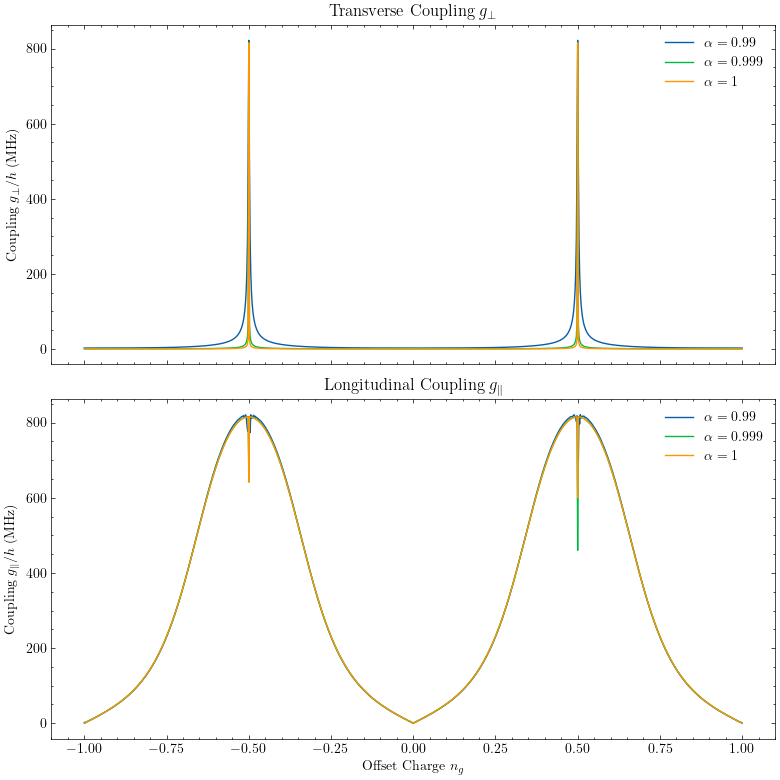

In [13]:
ng_vals = np.linspace(-1, 1, 1001)
alpha_vals_2 = [0.99, 0.999, 1]
results = {}

for alpha in alpha_vals_2:
    system2 = BellCircuit2(Ejp=5e9, Cjp=2e-15, Lp=200e-9, Cp=2e-15, Cg=0e-15, 
                 Cr=100e-15, Lr=10e-9, Ccp=10e-15, Cct=10e-15,
                 Ejt=5e9, Cjt=4e-15, Ct=40e-15, flux=flux, ng=0.0, ncut=5, alpha=alpha)
    
    g_transverse_ng = []
    g_longitudinal_ng = []
    
    for ng in tqdm(ng_vals):
        system2.ng = ng
        
        g_perp = np.abs(system2.calc_g_perp(update=True))   # transverse
        g_parr = np.abs(system2.calc_g_parr(update=True))   # longitudinal
        
        g_transverse_ng.append(g_perp)
        g_longitudinal_ng.append(g_parr)

        if ng==0.25:
            print(f"Junction asymmetry={alpha:.2f}, longitudinal coupling at ng=0.25: {g_parr:.3f} GHz")
    
    results[alpha] = (g_transverse_ng, g_longitudinal_ng)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

for alpha in alpha_vals_2:
    g_transverse_ng, g_longitudinal_ng = results[alpha]
    axs[0].plot(ng_vals, g_transverse_ng, label=fr"$\alpha={alpha}$")
    axs[1].plot(ng_vals, g_longitudinal_ng, label=fr"$\alpha={alpha}$")

axs[0].set_ylabel("Coupling $g_\\perp/h$ (MHz)")
axs[0].set_title("Transverse Coupling $g_\\perp$")
axs[0].legend()

axs[1].set_xlabel("Offset Charge $n_g$")
axs[1].set_ylabel("Coupling $g_\\parallel/h$ (MHz)")
axs[1].set_title("Longitudinal Coupling $g_\\parallel$")
axs[1].legend()

plt.tight_layout()
plt.show()